In [47]:
import pandas as pd
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [48]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [50]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [51]:
#Which values in TotalCharges cannot be converted to numbers?
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [52]:
#Let's see those 11 customers
df.loc[
    pd.to_numeric(df["TotalCharges"], errors="coerce").isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [53]:
# Convert TotalCharges correctly

# Now we can safely convert it to numeric.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [54]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [55]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [56]:
churn_summary = df["Churn"].value_counts().to_frame("count")
churn_summary["percentage"] = (
    churn_summary["count"] / len(df) * 100
)

churn_summary

,count,percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


In [57]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [58]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
X.shape, y.shape

((7043, 20), (7043,))

In [59]:
X.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [60]:
X.select_dtypes(include="object").columns

C:\Users\shaik.mohammedyasin\AppData\Local\Temp\ipykernel_6296\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [61]:
# Why are we manually creating these lists?

# Because data type alone isn't always enough.

# We just discovered exactly that:

# SeniorCitizen
# Python sees → number
# We understand → category

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "SeniorCitizen",
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [62]:
X["TotalCharges"].isna().sum()

np.int64(11)

In [63]:
X.loc[X["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [64]:
X.loc[X["TotalCharges"].isna(), "tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [65]:
X["TotalCharges"] = X["TotalCharges"].fillna(0)

In [66]:
X["TotalCharges"].isna().sum()

np.int64(0)

In [67]:
X = X.drop("customerID", axis=1)

In [68]:
X.shape

(7043, 19)

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [72]:
X_train["Contract"].value_counts()

Contract
Month-to-month    3102
Two year          1359
One year          1173
Name: count, dtype: int64

In [73]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")

In [74]:
#Encoder is for catogorical missing values to handle
#Converts categories into numerical columns
from sklearn.pipeline import Pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("encoder", encoder)
    ]
)
categorical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one

In [112]:
##SimpleImputer is for numeric missing values to handle
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [113]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [114]:
X_train_processed = preprocessor.fit_transform(X_train)

In [115]:
X_test_processed = preprocessor.transform(X_test)

In [116]:
X_train_processed.shape

(5634, 46)

In [117]:
X_test_processed.shape

(1409, 46)

In [118]:
y_train = y_train.map({"No": 0, "Yes": 1})

In [119]:
y_train.value_counts()

Series([], Name: count, dtype: int64)

In [121]:
y_test.value_counts()

Churn
0    1035
1     374
Name: count, dtype: int64

In [122]:
y_test = y_test.map({"No": 0, "Yes": 1})

In [123]:
y_test.value_counts()

Series([], Name: count, dtype: int64)

In [124]:
y_test.head()

437    NaN
2280   NaN
2235   NaN
4460   NaN
3761   NaN
Name: Churn, dtype: float64

In [125]:
y = df["Churn"]

y_train, y_test = train_test_split(
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [126]:
y_train.value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

In [127]:
y_test.value_counts()

Churn
No     1035
Yes     374
Name: count, dtype: int64

In [128]:
y = df["Churn"]

y_train, y_test = train_test_split(
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [129]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [130]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [131]:
y_test.value_counts()

Churn
0    1035
1     374
Name: count, dtype: int64

In [132]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [137]:
model.fit(X_train_processed, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [134]:
from sklearn.preprocessing import StandardScaler
# went back to nuric pipeline and added standard scalar

In [138]:
y_pred = model.predict(X_test_processed)

In [139]:
y_pred[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [140]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [141]:
comparison.head(20)

,Actual,Predicted
437,0,0
2280,0,1
2235,0,0
4460,0,0
3761,0,0
5748,0,1
3568,0,0
2976,0,0
5928,0,0
1639,1,0


In [142]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.8055358410220014

In [143]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision, recall, f1

(0.6572327044025157, 0.5588235294117647, 0.6040462427745664)

In [ ]:
#Confusion Matrix

#                     Predicted
#                   No       Yes
#                 ─────────────────
# Actual No       926       109
# Actual Yes      165       209
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[926, 109],
       [165, 209]])

In [ ]:
#predict_proba() gives two probabilities for every customer:
y_proba = model.predict_proba(X_test_processed)[:, 1]
y_proba[:20]

array([0.04605857, 0.68364788, 0.05872542, 0.40112026, 0.02163739,
       0.60314635, 0.44753099, 0.13019399, 0.00284876, 0.3955416 ,
       0.26855877, 0.06268806, 0.1289542 , 0.68609328, 0.12867581,
       0.05838543, 0.03273458, 0.63699808, 0.18017848, 0.08477616])

In [147]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)

roc_auc

0.8420341522643313

In [148]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [149]:
len(fpr), len(tpr), len(thresholds)

(409, 409, 409)

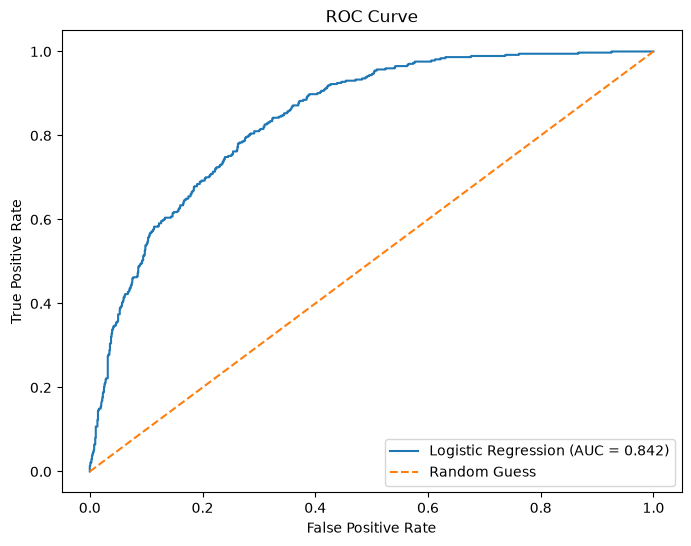

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [ ]:
#"What is the difference between ROC curve and ROC-AUC?"
# ROC curve shows the relationship between True Positive Rate and False Positive Rate at different classification thresholds.

# ROC-AUC summarizes the overall performance of that ROC curve into a single number.
#ROC-AUC measures classification performance

In [151]:
fpr[:10]

array([0.        , 0.        , 0.        , 0.00096618, 0.00096618,
       0.00289855, 0.00289855, 0.00386473, 0.00386473, 0.00483092])

In [152]:
tpr[:10]

array([0.        , 0.0026738 , 0.01336898, 0.01336898, 0.02139037,
       0.02139037, 0.02941176, 0.02941176, 0.03743316, 0.03743316])

In [153]:
thresholds[:10]

array([       inf, 0.85504134, 0.81905935, 0.81793896, 0.81632713,
       0.81176644, 0.79490709, 0.79483896, 0.78901698, 0.78661054])

In [154]:
roc_data = pd.DataFrame({
    "Threshold": thresholds,
    "FPR": fpr,
    "TPR": tpr
})

roc_data.head(10)

,Threshold,FPR,TPR
0,inf,0.000000,0.000000
1,0.855041,0.000000,0.002674
2,0.819059,0.000000,0.013369
3,0.817939,0.000966,0.013369
4,0.816327,0.000966,0.021390
5,0.811766,0.002899,0.021390
6,0.794907,0.002899,0.029412
7,0.794839,0.003865,0.029412
8,0.789017,0.003865,0.037433
9,0.786611,0.004831,0.037433


In [ ]:
# |                        | **Model says NO churn** | **Model says YES churn** |
# | ---------------------- | ----------------------: | -----------------------: |
# | **Actually NO churn**  |    🟢 **True Negative** |    🔴 **False Positive** |
# | **Actually YES churn** |   🔴 **False Negative** |     🟢 **True Positive** |


In [155]:
#another alogorith or model DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(
    random_state=42
)
tree_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [156]:
tree_pred = tree_model.predict(X_test_processed)

In [157]:
tree_pred[:20]

array([0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [158]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

tree_accuracy, tree_precision, tree_recall, tree_f1

(0.7182398864442867, 0.47103274559193953, 0.5, 0.48508430609597925)

In [159]:
tree_train_pred = tree_model.predict(X_train_processed)

tree_train_accuracy = accuracy_score(y_train, tree_train_pred)
tree_test_accuracy = accuracy_score(y_test, tree_pred)

tree_train_accuracy, tree_test_accuracy

(0.9980475683351083, 0.7182398864442867)

In [160]:
for depth in [2, 3, 5, 7, 10]:
    
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    tree.fit(X_train_processed, y_train)
    
    train_pred = tree.predict(X_train_processed)
    test_pred = tree.predict(X_test_processed)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    print(
        "max_depth =", depth,
        "| train =", round(train_accuracy, 4),
        "| test =", round(test_accuracy, 4)
    )

max_depth = 2 | train = 0.7654 | test = 0.7509
max_depth = 3 | train = 0.7914 | test = 0.7821
max_depth = 5 | train = 0.8039 | test = 0.7984
max_depth = 7 | train = 0.8209 | test = 0.7864
max_depth = 10 | train = 0.8788 | test = 0.7544


In [161]:
tree5_model = DecisionTreeClassifier(
    max_depth=5, #performed well with small gap between train and test accuracy
    random_state=42
)

tree5_model.fit(X_train_processed, y_train)

tree5_pred = tree5_model.predict(X_test_processed)

In [162]:
tree5_accuracy = accuracy_score(y_test, tree5_pred)
tree5_precision = precision_score(y_test, tree5_pred)
tree5_recall = recall_score(y_test, tree5_pred)
tree5_f1 = f1_score(y_test, tree5_pred)

tree5_accuracy, tree5_precision, tree5_recall, tree5_f1

(0.7984386089425124,
 0.6347305389221557,
 0.5668449197860963,
 0.5988700564971752)

In [163]:
tree5_proba = tree5_model.predict_proba(X_test_processed)[:, 1]

tree5_roc_auc = roc_auc_score(y_test, tree5_proba)

tree5_roc_auc

0.829725645198791

In [164]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [165]:
rf_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [166]:
rf_pred = rf_model.predict(X_test_processed)

rf_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [167]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

rf_accuracy, rf_precision, rf_recall, rf_f1

(0.7821149751596878,
 0.6135593220338983,
 0.4839572192513369,
 0.5411061285500748)

In [168]:
rf_proba = rf_model.predict_proba(X_test_processed)[:, 1]

rf_roc_auc = roc_auc_score(y_test, rf_proba)

rf_roc_auc

0.8196504688832054

In [169]:
# n_estimators

# How many trees should the forest contain?

# 100 trees
# 200 trees

# min_samples_split

# How many samples must exist in a node before the tree is allowed to split it?

# Larger value → harder to split → simpler tree.

# min_samples_leaf

# Minimum number of samples that must remain in a leaf.

# Larger value → prevents extremely tiny leaves → helps reduce overfitting.
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [170]:
rf_param_grid

{'n_estimators': [100, 200],
 'max_depth': [5, 10, None],
 'min_samples_split': [2, 5],
 'min_samples_leaf': [1, 2]}

In [172]:
from sklearn.model_selection import GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [ ]:
# estimator
# RandomForestClassifier(random_state=42)
# This is the model we want to tune.

# scoring="roc_auc"
# This is particularly important for our churn problem.
# We're telling GridSearchCV:
# "When deciding which Random Forest is best, use ROC-AUC."
# We could use accuracy, F1, recall, etc., but we're currently using ROC-AUC because '
# 'we already established that the classes are imbalanced and we care about the model's ability
# to distinguish churners from non-churners.

# n_jobs=-1
# This means: Use all available CPU cores for the computation.
# It doesn't change the model's logic or accuracy. It mainly makes GridSearchCV faster.

In [ ]:
# We are not giving X_test_processed or y_test to GridSearchCV.

# That's intentional.
# Our workflow is:

# X_train_processed
#        ↓
#    GridSearchCV
#        ↓
#   5-fold CV
#        ↓
# Best Random Forest
#        ↓
# X_test_processed
#        ↓
# FINAL evaluation

In [173]:
rf_grid_search.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [174]:
rf_grid_search.best_params_

{'max_depth': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [175]:
rf_grid_search.best_score_

np.float64(0.8448609065366174)

In [176]:
best_rf = rf_grid_search.best_estimator_
best_rf

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [ ]:
#We have selected the best model using training data + cross-validation.

# Now we need to ask:

# How well does this selected model perform on completely untouched test data?

In [179]:
best_rf_pred = best_rf.predict(X_test_processed)

In [181]:
best_rf_proba = best_rf.predict_proba(X_test_processed)[:, 1]
best_rf_proba 

array([0.06275714, 0.57957525, 0.08431252, ..., 0.13132506, 0.02359732,
       0.03101597], shape=(1409,))

In [182]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, best_rf_proba))

Accuracy : 0.794889992902768
Precision: 0.6748971193415638
Recall   : 0.4385026737967914
F1 Score : 0.5316045380875203
ROC-AUC  : 0.8407269627218477


In [186]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    
    threshold_pred = (best_rf_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, threshold_pred)
    precision = precision_score(y_test, threshold_pred)
    recall = recall_score(y_test, threshold_pred)
    f1 = f1_score(y_test, threshold_pred)
    
    print(
        "Threshold =", threshold,
        "| Accuracy =", round(accuracy, 4),
        "| Precision =", round(precision, 4),
        "| Recall =", round(recall, 4),
        "| F1 =", round(f1, 4)
    )

Threshold = 0.3 | Accuracy = 0.748 | Precision = 0.5169 | Recall = 0.7754 | F1 = 0.6203
Threshold = 0.4 | Accuracy = 0.7949 | Precision = 0.6055 | Recall = 0.6524 | F1 = 0.6281
Threshold = 0.5 | Accuracy = 0.7949 | Precision = 0.6749 | Recall = 0.4385 | F1 = 0.5316
Threshold = 0.6 | Accuracy = 0.7807 | Precision = 0.7559 | Recall = 0.2567 | F1 = 0.3832
Threshold = 0.7 | Accuracy = 0.741 | Precision = 0.9091 | Recall = 0.0267 | F1 = 0.0519


In [187]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8055,
        0.7984,
        0.7949
    ],
    "Precision": [
        0.6572,
        0.6347,
        0.6749
    ],
    "Recall": [
        0.5588,
        0.5668,
        0.4385
    ],
    "F1": [
        0.6040,
        0.5989,
        0.5316
    ],
    "ROC-AUC": [
        0.8420,
        0.8297,
        0.8407
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
1,Decision Tree,0.7984,0.6347,0.5668,0.5989,0.8297
2,Random Forest,0.7949,0.6749,0.4385,0.5316,0.8407


In [188]:
cm_rf = confusion_matrix(y_test, best_rf_pred)
cm_rf

array([[956,  79],
       [210, 164]])

In [189]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
1,Decision Tree,0.7984,0.6347,0.5668,0.5989,0.8297
2,Random Forest,0.7949,0.6749,0.4385,0.5316,0.8407


In [190]:
from sklearn.linear_model import LogisticRegression

lr_proba = model.predict_proba(X_test_processed)[:, 1]

lr_proba[:20]

array([0.04605857, 0.68364788, 0.05872542, 0.40112026, 0.02163739,
       0.60314635, 0.44753099, 0.13019399, 0.00284876, 0.3955416 ,
       0.26855877, 0.06268806, 0.1289542 , 0.68609328, 0.12867581,
       0.05838543, 0.03273458, 0.63699808, 0.18017848, 0.08477616])

In [191]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:

    threshold_pred = (lr_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, threshold_pred)
    precision = precision_score(y_test, threshold_pred)
    recall = recall_score(y_test, threshold_pred)
    f1 = f1_score(y_test, threshold_pred)

    print(
        "Threshold =", threshold,
        "| Accuracy =", round(accuracy, 4),
        "| Precision =", round(precision, 4),
        "| Recall =", round(recall, 4),
        "| F1 =", round(f1, 4)
    )

Threshold = 0.3 | Accuracy = 0.7495 | Precision = 0.5193 | Recall = 0.754 | F1 = 0.615
Threshold = 0.4 | Accuracy = 0.7771 | Precision = 0.5682 | Recall = 0.6684 | F1 = 0.6143
Threshold = 0.5 | Accuracy = 0.8055 | Precision = 0.6572 | Recall = 0.5588 | F1 = 0.604
Threshold = 0.6 | Accuracy = 0.7991 | Precision = 0.7177 | Recall = 0.4011 | F1 = 0.5146
Threshold = 0.7 | Accuracy = 0.7665 | Precision = 0.7419 | Recall = 0.1845 | F1 = 0.2955


In [192]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression ROC curve
lr_fpr, lr_tpr, lr_thresholds = roc_curve(
    y_test,
    lr_proba
)

# Random Forest ROC curve
rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    best_rf_proba
)

# ROC-AUC values
lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, best_rf_proba)

print("Logistic Regression ROC-AUC =", round(lr_auc, 4))
print("Random Forest ROC-AUC =", round(rf_auc, 4))

Logistic Regression ROC-AUC = 0.842
Random Forest ROC-AUC = 0.8407


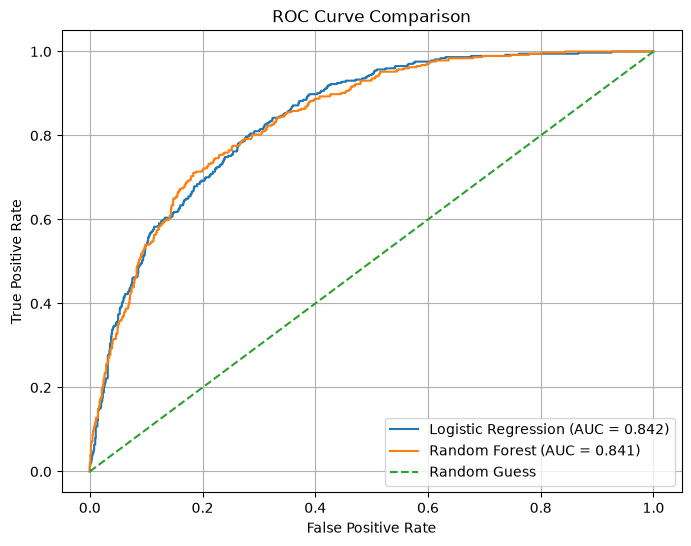

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()

In [194]:
feature_names = preprocessor.get_feature_names_out()

len(feature_names)

46

In [195]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

feature_importance

,Feature,Coefficient
0,num__tenure,-1.255202
1,num__MonthlyCharges,-0.601168
2,num__TotalCharges,0.532592
3,cat__SeniorCitizen_0,-0.217646
4,cat__SeniorCitizen_1,-0.070924
5,cat__gender_Female,-0.155230
6,cat__gender_Male,-0.133340
7,cat__Partner_No,-0.155036
8,cat__Partner_Yes,-0.133534
9,cat__Dependents_No,-0.032387


In [196]:
import pandas as pd

feature_importance_sorted = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance_sorted

,Feature,Coefficient
17,cat__InternetService_Fiber optic,0.648027
37,cat__Contract_Month-to-month,0.585998
2,num__TotalCharges,0.532592
36,cat__StreamingMovies_Yes,0.212270
33,cat__StreamingTV_Yes,0.211922
44,cat__PaymentMethod_Electronic check,0.205585
19,cat__OnlineSecurity_No,0.165550
28,cat__TechSupport_No,0.141320
15,cat__MultipleLines_Yes,0.113364
41,cat__PaperlessBilling_Yes,0.042165


In [197]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

numeric_pipeline_final = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_final = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_final, numeric_features),
        ("cat", categorical_pipeline_final, categorical_features)
    ]
)

final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, final_pred)
precision = precision_score(y_test, final_pred)
recall = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)
roc_auc = roc_auc_score(y_test, final_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.604
ROC-AUC  : 0.842


In [199]:
import joblib

joblib.dump(
    final_model,
    "../models/customer_churn_pipeline.pkl"
)

['../models/customer_churn_pipeline.pkl']

In [ ]:
# Because saving a model isn't enough.
# We want to prove: "I can save my trained ML pipeline and later load it back and use it."
# That's something you can legitimately mention in your portfolio.

import joblib

loaded_model = joblib.load(
    "../models/customer_churn_pipeline.pkl"
)

loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [201]:
import numpy as np

loaded_pred = loaded_model.predict(X_test)

loaded_proba = loaded_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(loaded_pred[:10])

print("\nFirst 10 churn probabilities:")
print(np.round(loaded_proba[:10], 4))

First 10 predictions:
[0 1 0 0 0 1 0 0 0 0]

First 10 churn probabilities:
[0.0461 0.6836 0.0587 0.4011 0.0216 0.6031 0.4475 0.1302 0.0028 0.3955]


In [202]:
import numpy as np

predictions_match = np.array_equal(
    final_pred,
    loaded_pred
)

probabilities_match = np.allclose(
    final_proba,
    loaded_proba
)

print("Predictions match:", predictions_match)
print("Probabilities match:", probabilities_match)

Predictions match: True
Probabilities match: True


In [203]:
# adding new customer and using loaded model to predict

import pandas as pd

new_customer = pd.DataFrame({
    "SeniorCitizen": [0],
    "gender": ["Male"],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.0],
    "TotalCharges": [425.0]
})

new_customer

,SeniorCitizen,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,Male,No,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,425.0


In [204]:
import numpy as np

prediction = loaded_model.predict(new_customer)

probability = loaded_model.predict_proba(new_customer)[:, 1]

print("Prediction:", prediction[0])
print("Churn probability:", round(probability[0], 4))

Prediction: 1
Churn probability: 0.7851


In [205]:
prediction_label = "Yes" if prediction[0] == 1 else "No"

print("Will customer churn?:", prediction_label)
print("Churn probability:", round(probability[0] * 100, 2), "%")

Will customer churn?: Yes
Churn probability: 78.51 %


In [206]:
from pathlib import Path

project_path = Path("..")

for path in project_path.iterdir():
    print(path)

..\data
..\models
..\notebooks
..\README.md
..\src
